In [ ]:
#load library
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [ ]:
#load data
from google.colab import drive
drive.mount('/content/drive')
PATH = r'/content/drive/MyDrive/pose folder data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. ResNet50에 맞춘 표준 이미지 크기
IMG_SIZE = (224, 224)

# 3. 저장될 .npz 파일 경로 (Colab의 임시 저장 공간)
SAVE_PATH = r'/content/drive/MyDrive/pose folder data/pose_estimator.npz'

In [ ]:
dirNames = os.listdir(PATH)
print(dirNames)

['Bad', 'Good', 'pose_estimator.h5', 'pose_estimator.npz', 'predictions.png', 'myResNet50.h5']


In [ ]:
Xdata, Ydata = [], []

if dirNames: # dirNames 리스트가 비어있지 않을 때만 실행
    print("데이터셋 생성을 시작합니다... (로컬 경로에서 읽는 중)")
    start_time = time.time()

    # enumerate를 사용해 클래스 이름(name)과 숫자 레이블(index)을 동시에 가져옴
    for index, name in enumerate(dirNames):
        classPath = os.path.join(PATH, name)

        if not os.path.isdir(classPath):
            continue

        imgNames = os.listdir(classPath)
        print(f"'{name}' 클래스(Label: {index}) 처리 중... (파일 {len(imgNames)}개)")

        for imgName in imgNames:
            imgPath = os.path.join(classPath, imgName)

            try:
                # 1. 이미지를 컬러(3채널)로 읽어들임
                img = cv2.imread(imgPath, cv2.IMREAD_COLOR)

                # 2. 이미지 로드 실패 시
                if img is None:
                    print(f"  경고: {imgPath} 파일을 읽을 수 없습니다. 건너뜁니다.")
                    continue

                # 3. 이미지 크기 통일
                img_resized = cv2.resize(img, IMG_SIZE)

                # 4. 데이터 리스트에 추가
                Xdata.append(img_resized)
                Ydata.append(index)

            except Exception as e:
                print(f"  오류: {imgPath} 처리 중 예외 발생: {e}")
      # NumPy 배열로 변환
    Xdata = np.array(Xdata)
    Ydata = np.array(Ydata)

    end_time = time.time()
    print("\n...데이터셋 생성 완료.")
    print(f"총 소요 시간: {end_time - start_time:.2f} 초")
    print(f"Xdata (이미지 데이터) shape: {Xdata.shape}")
    print(f"Ydata (레이블 데이터) shape: {Ydata.shape}")

    # .npz 파일로 저장
    np.savez_compressed(PATH, X=Xdata, Y=Ydata)
    print(f"데이터셋이 {PATH } 파일로 성공적으로 저장되었습니다.")
else:
    print("처리할 데이터가 없습니다. '셀 1'의 경로와 실행을 확인하세요.")

데이터셋 생성을 시작합니다... (로컬 경로에서 읽는 중)
'Bad' 클래스(Label: 0) 처리 중... (파일 1357개)
'Good' 클래스(Label: 1) 처리 중... (파일 1026개)

...데이터셋 생성 완료.
총 소요 시간: 64.70 초
Xdata (이미지 데이터) shape: (2383, 224, 224, 3)
Ydata (레이블 데이터) shape: (2383,)
데이터셋이 /content/drive/MyDrive/pose folder data 파일로 성공적으로 저장되었습니다.


In [ ]:
Xdata = np.array(Xdata)
Ydata = np.array(Ydata)
print(Xdata.shape, Ydata.shape)

(2383, 224, 224, 3) (2383,)


In [ ]:
# .npz 파일로 저장
np.savez_compressed(SAVE_PATH, X=Xdata, Y=Ydata)
print(f"데이터셋이 {SAVE_PATH} 파일로 성공적으 저장되었습니다.")

데이터셋이 /content/drive/MyDrive/pose folder data/pose_estimator.npz 파일로 성공적으 저장되었습니다.


--- ResNet-50 ---------------

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
data = np.load(r'/content/drive/MyDrive/pose folder data/pose_estimator.npz')
dataX, dataY = data['X'], data['Y']
print(dataX.shape, dataY.shape)

(2383, 224, 224, 3) (2383,)


In [ ]:
dataX = dataX / 255.0
num_classes = len(np.unique(dataY))
dataY_categorical = to_categorical(dataY, num_classes=num_classes)
X_train, X_test, y_train, y_test = train_test_split(
    dataX, dataY_categorical, test_size=0.2, random_state=42, stratify=dataY_categorical
)
del dataX, dataY, dataY_categorical

In [ ]:
from tensorflow.keras.applications import ResNet50,ResNet101
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#Create EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=5,              # stop if no improvement for 5 epochs
    restore_best_weights=True # load best model weights at the end
)

# Build ResNet model
input_tensor = Input(shape=X_train.shape[1:])  # (H, W, C)
base_model = ResNet50(
    input_tensor=input_tensor,
    include_top=False,
    weights='imagenet'
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
outputs = Dense(y_train.shape[1], activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train + validation
history = model.fit(
    X_train,
    y_train,
    epochs = 100,
    batch_size=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1                 # progress bar
)

# 4. (선택) history 안에 뭐 들어있는지 확인
print("\nHistory keys:", history.history.keys())

Epoch 1/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 111s 287ms/step - accuracy: 0.8751 - loss: 0.3348 - val_accuracy: 0.5702 - val_loss: 0.7422
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9384 - loss: 0.1714 - val_accuracy: 0.5702 - val_loss: 1.1625
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - accuracy: 0.9420 - loss: 0.1219 - val_accuracy: 0.5702 - val_loss: 0.6957
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - accuracy: 0.9641 - loss: 0.1023 - val_accuracy: 0.4088 - val_loss: 0.6888
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - accuracy: 0.9663 - loss: 0.0816 - val_accuracy: 0.5702 - val_loss: 7.7981
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - accuracy: 0.9732 - loss: 0.0693 - val_accuracy: 0.5702 - val_loss: 30.5718
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - accuracy: 0.9869 - loss: 0.0396 - val_accuracy: 0.8553 - val_loss: 0.3423
Epoch 8/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - accuracy: 0.9907

In [ ]:
# 모델을 검증하는 위치
test_loss, test_accuracy = model.evaluate(X_test, y_test)
# evaluate : 학습 과정을 통해 학습된 모델을 이용하여 테스트를 진행
print(f'Test Accuracy: {test_accuracy}')

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 382ms/step - accuracy: 0.9014 - loss: 0.2024
Test Accuracy: 0.9182389974594116


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.1834
Test Accuracy: 0.9182


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
이미지 저장: predictions.png


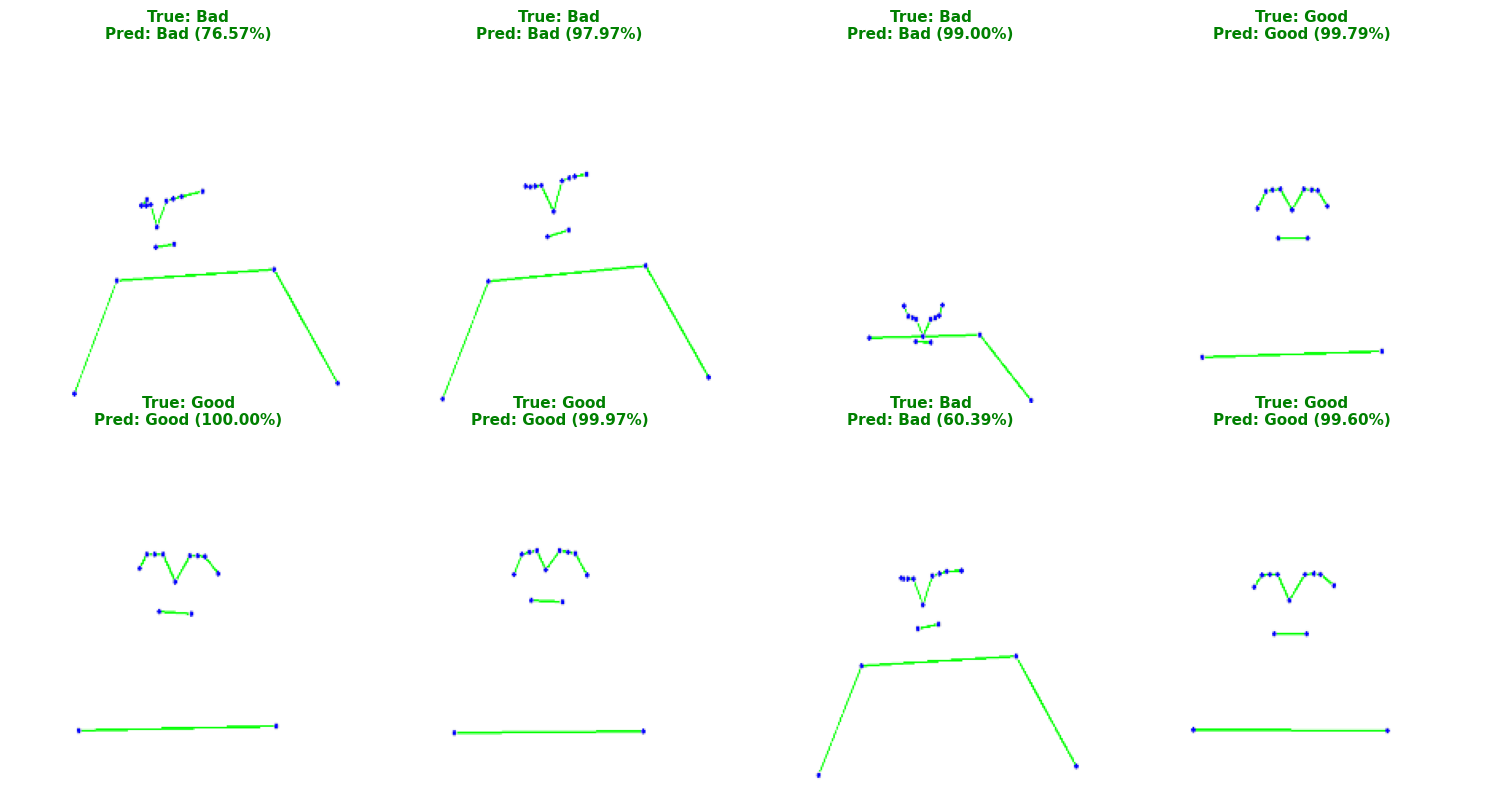

In [ ]:
# 클래스 이름
class_names = ['Bad', 'Good']

# 2. 테스트 이미지 중에서 8장 랜덤으로 뽑기
num_images = 8
idx = np.random.choice(len(X_test), num_images, replace=False)
test_images = X_test[idx]
true_labels = y_test[idx]

# y_test가 one-hot이면 인덱스로 변환
if true_labels.ndim > 1:
    true_idx = np.argmax(true_labels, axis=1)
else:
    true_idx = true_labels

# 3. 모델 예측
pred_probs = model.predict(test_images)  # shape: (8, num_classes or 1)

# 이진 분류(sigmoid) vs 다중 분류(softmax) 모두 대응
if pred_probs.shape[1] == 1:       # sigmoid 출력 (binary)
    prob = pred_probs.squeeze()    # (8,)
    pred_idx = (prob >= 0.5).astype(int)
    # confidence: 예측한 클래스의 확률
    confidences = np.where(pred_idx == 1, prob, 1 - prob)
else:                              # softmax 출력 (multi-class)
    pred_idx = np.argmax(pred_probs, axis=1)  # (8,)
    confidences = pred_probs[np.arange(num_images), pred_idx]

# 4. 시각화를 위한 디프리프로세싱 함수
def deprocess(img):
    img = img.copy().astype("float32")
    # 만약 0~255 범위면 0~1로 스케일링
    if img.max() > 1.0:
        img /= 255.0
    # preprocess_input 썼다면 여기서 mean/std 되돌리는 코드 넣어도 됨
    return np.clip(img, 0.0, 1.0)

# 5. 그림 그리기 (2 x 4 그리드)
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = deprocess(test_images[i])
    ax.imshow(img)
    ax.axis('off')

    t_name = class_names[int(true_idx[i])]
    p_name = class_names[int(pred_idx[i])]

    color = 'green' if t_name == p_name else 'red'
    ax.set_title(
        f"True: {t_name}\nPred: {p_name} ({confidences[i]*100:.2f}%)",
        color=color,
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig(r"/content/drive/MyDrive/pose folder data/predictions.png", dpi=100, bbox_inches="tight")
print("이미지 저장: predictions.png")
plt.show()


In [ ]:
#모델 저장
model.save(r'/content/drive/MyDrive/pose folder data/pose_estimator.h5')